In [2]:
import pandas as pd
import numpy as np

# CSV 파일 읽기
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/abalone.csv')

df.head()

,id,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [3]:
df.columns

Index(['id', 'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
       'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [4]:
df.isnull().sum()

,0
id,0
Sex,0
Length,0
Diameter,0
Height,0
Whole_weight,0
Shucked_weight,0
Viscera_weight,0
Shell_weight,0
Rings,0


In [5]:
# 1. 'id' 컬럼 삭제
df = df.drop('id', axis=1)

# 2. 'Sex' 컬럼 원-핫 인코딩 (문자열 -> 숫자로 변환)
df = pd.get_dummies(df, columns=['Sex'])

# 3. 특성(X)과 정답(y) 분리
X = df.drop('Rings', axis=1) # Rings를 제외한 나머지가 학습용 데이터
y = df['Rings']

X.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_F,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,False,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,False,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,True,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,False,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,False,True,False


Epoch 1/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 70.6426 - mae: 7.4672 - val_loss: 27.9699 - val_mae: 4.2359
Epoch 2/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.6993 - mae: 3.4640 - val_loss: 11.8930 - val_mae: 2.4853
Epoch 3/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.1813 - mae: 2.2415 - val_loss: 6.6875 - val_mae: 1.7607
Epoch 4/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.0072 - mae: 1.8919 - val_loss: 5.7533 - val_mae: 1.6828
Epoch 5/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.1586 - mae: 1.8937 - val_loss: 5.6091 - val_mae: 1.6314
Epoch 6/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8869 - mae: 1.8449 - val_loss: 5.3906 - val_mae: 1.6501
Epoch 7/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7131 - mae: 1.8315 - val_loss: 5.2121 - val_mae: 1.6198
Epoch 8/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1868 - mae: 1.7602 - val_loss: 5.1464 - val_mae: 1.6438
Epoch 9/100
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 

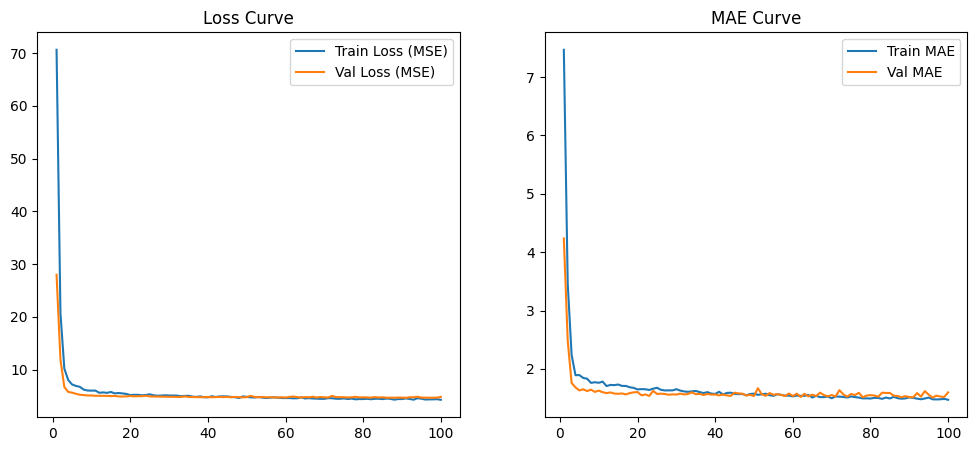


[Regression Report]
Mean Absolute Error (MAE): 1.5063
R2 Score: 0.5865


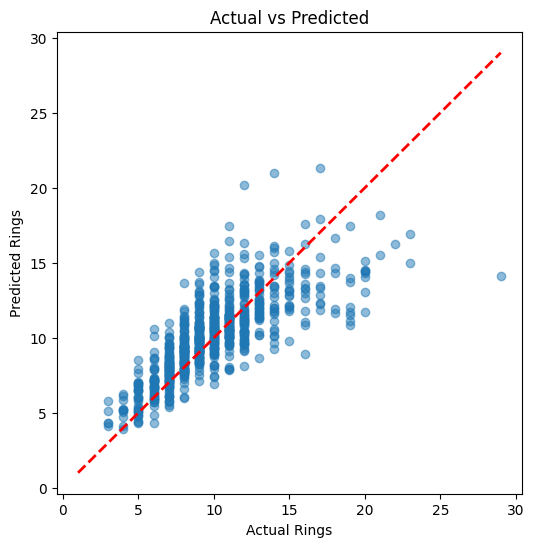

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score # 회귀용 지표로 변경
from tensorflow.keras import layers, models, Input

# 1. 데이터 로드 및 전처리
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/abalone.csv') # 파일 경로에 맞춰 수정하세요
df.columns = df.columns.str.strip()

# 'id' 컬럼 삭제
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# 'Sex' 컬럼 원-핫 인코딩
df = pd.get_dummies(df, columns=['Sex'])

# 특성(X)과 정답(y) 분리
X = df.drop('Rings', axis=1)
y = df['Rings']

# 2. 데이터 분할
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. 데이터 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 4. 모델 구축 (회귀용으로 수정)
model = models.Sequential([
    Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1) # [수정] 출력층 노드를 1개로 (나이 숫자 하나를 예측)
])

model.compile(
    optimizer="adam",
    loss="mse", # [수정] 손실함수를 평균제곱오차(MSE)로 변경
    metrics=["mae"] # [수정] 평가지표를 평균절대오차(MAE)로 변경
)

# 5. 모델 학습
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100, # 회귀는 조금 더 많이 학습시키는 것이 좋습니다
    batch_size=32,
    verbose=1
)

# 6. 예측 및 결과 분석
y_pred = model.predict(X_test).flatten() # 1차원 배열로 변환

# 7. 시각화 (Loss & MAE)
epochs_range = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['loss'], label='Train Loss (MSE)')
plt.plot(epochs_range, history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Loss Curve'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['mae'], label='Train MAE')
plt.plot(epochs_range, history.history['val_mae'], label='Val MAE')
plt.title('MAE Curve'); plt.legend()
plt.show()

# 8. 최종 리포트 (회귀용 지표)
print("\n[Regression Report]")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test, y_pred):.4f}")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")

# 실제값 vs 예측값 시각화
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Rings'); plt.ylabel('Predicted Rings')
plt.title('Actual vs Predicted')
plt.show()

In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

In [7]:
clf_lr = LogisticRegression(max_iter=5000)

clf_lr.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

Logistic Regression
Accuracy: 0.27751196172248804
[[ 0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  3  6  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  4  9 15  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  2 22 12  6  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  4 18 29 28 18  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  3 11 51 37  9  2  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  9 22 61 31  3  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  4 14 33 37 17  0  1  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  4  9 27 33 18  0  2  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  5 19 23 14  0  3  0  0  2  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  1  5 16 14  0  1  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  2  4 12  2  0  4  0  1  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1 10  5  0  2  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  1  5  5  0  1  0  0  1  0  0  0 

In [8]:
clf_svm = SVC()

clf_svm.fit(X_train, y_train)

pred_svm = clf_svm.predict(X_test)

print("\nSVM")
print("Accuracy:", accuracy_score(y_test, pred_svm))
print(confusion_matrix(y_test, pred_svm))


SVM
Accuracy: 0.2751196172248804
[[ 0  5  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  3  6  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  4  9 11  6  0  1  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  1  2 21 15  2  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  4 15 33 14 26  6  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  2 14 38 48 10  1  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  6 14 66 39  2  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  1  3  5 40 42 16  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  5  3 28 41 18  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  2 22 31 10  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  1  0  7 22  9  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  2 11 10  3  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  3 13  2  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  3  9  1  0  0  0  0  0  0  0  0  0  0  0  0  0]


In [9]:
clf_dt = DecisionTreeClassifier()

clf_dt.fit(X_train, y_train)

pred_dt = clf_dt.predict(X_test)

print("\nDecision Tree")
print("Accuracy:", accuracy_score(y_test, pred_dt))
print(confusion_matrix(y_test, pred_dt))


Decision Tree
Accuracy: 0.20813397129186603
[[ 3  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  3  5  1  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 1  7  9  5  8  2  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  2  6 11 16  9  3  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  2 20 27 30 10  5  1  0  1  1  1  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  3  9 21 27 24 16  5  4  2  2  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  4  5 27 37 20 13  9  4  2  3  2  0  1  0  0  0  0  0  0  0]
 [ 0  0  0  0  5 13 25 22 18  9  5  6  2  1  0  0  0  1  0  0  0  0  0]
 [ 0  0  0  2  4  7 14 29 14  6  5  5  4  0  1  4  0  0  0  0  0  0  0]
 [ 0  0  0  1  0  8 10 10  7 10  6  2  3  2  2  1  1  0  0  1  1  1  0]
 [ 0  0  0  0  0  3  9  4  4  6  4  1  0  1  2  1  1  1  0  0  2  0  0]
 [ 0  0  0  0  0  1  3  4  4  3  3  2  0  2  1  0  1  2  0  0  0  0  0]
 [ 0  0  0  0  0  1  3  1  2  5  1  0  2  0  1  1  0  0  1  0  0  0  0]
 [ 0  0  0  0  0  0

In [10]:
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Linear Regression MSE:", mean_squared_error(y_test, pred_lr))

Linear Regression MSE: 5.006878548779927


In [11]:
dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree MSE:", mean_squared_error(y_test, pred_dt))

Decision Tree MSE: 8.814593301435407


In [12]:
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest MSE:", mean_squared_error(y_test, pred_rf))

Random Forest MSE: 4.692706937799043
